# 02 — Exploração Visual | Frota Alugada por Região
**Mottu | Time de Previsão de Demanda**  
Análise exploratória da demanda de motos alugadas por região no Brasil.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
COR_MOTTU = '#FF6B00'

print('✅ Imports OK')

✅ Imports OK


In [22]:
# ── Carregar CSV ──────────────────────────────────────────────
df = pd.read_csv('data/raw/frota_alugada_historico.csv', parse_dates=['ano_mes'])

print(f'Shape: {df.shape}')
print(f'Período: {df.ano_mes.min().strftime("%b/%Y")} → {df.ano_mes.max().strftime("%b/%Y")}')
print(f'Regiões: {df.regiao.nunique()}')
df.head()

Shape: (1939, 3)
Período: Mar/2024 → Feb/2026
Regiões: 83


,ano_mes,regiao,media_motos_alugadas_dia
0,2026-02-01,Alagoinhas,18.0
1,2026-02-01,Aracaju,19.0
2,2026-02-01,Aracati,25.0
3,2026-02-01,Arapiraca,20.0
4,2026-02-01,Araçatuba,12.0


---
## 1 — Demanda Total por Mês (Brasil)

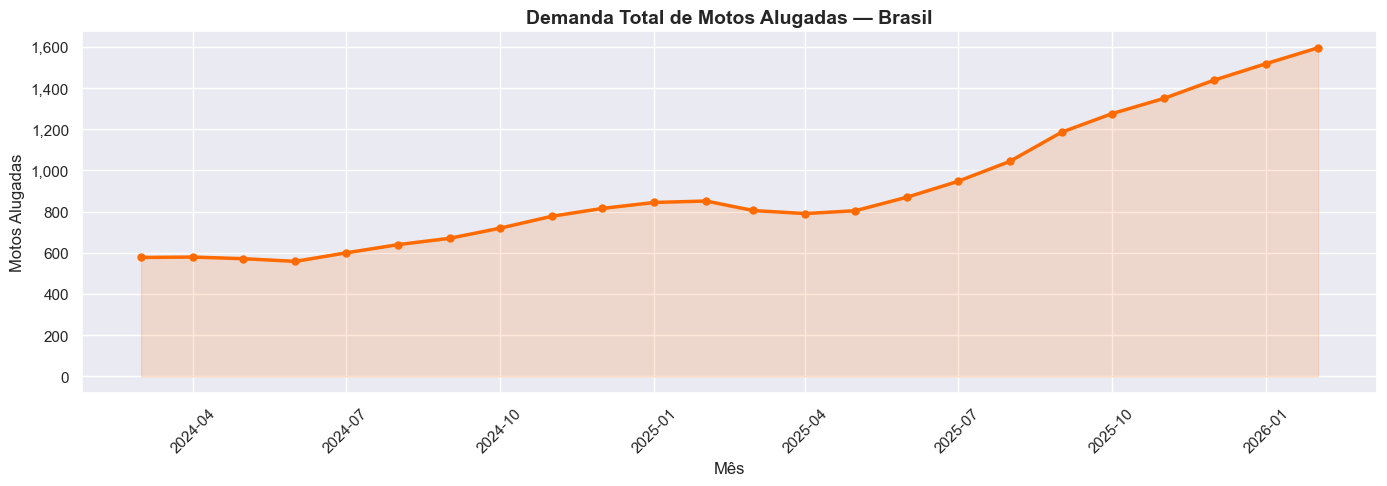

In [23]:
demanda_mensal = (
    df.groupby('ano_mes')['media_motos_alugadas_dia']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(demanda_mensal['ano_mes'], demanda_mensal['media_motos_alugadas_dia'],
        color=COR_MOTTU, linewidth=2.5, marker='o', markersize=5)
ax.fill_between(demanda_mensal['ano_mes'], demanda_mensal['media_motos_alugadas_dia'],
                alpha=0.15, color=COR_MOTTU)

ax.set_title('Demanda Total de Motos Alugadas — Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Motos Alugadas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/raw/grafico_demanda_total.png', dpi=150)
plt.show()

---
## 2 — Top 15 Regiões por Volume Total

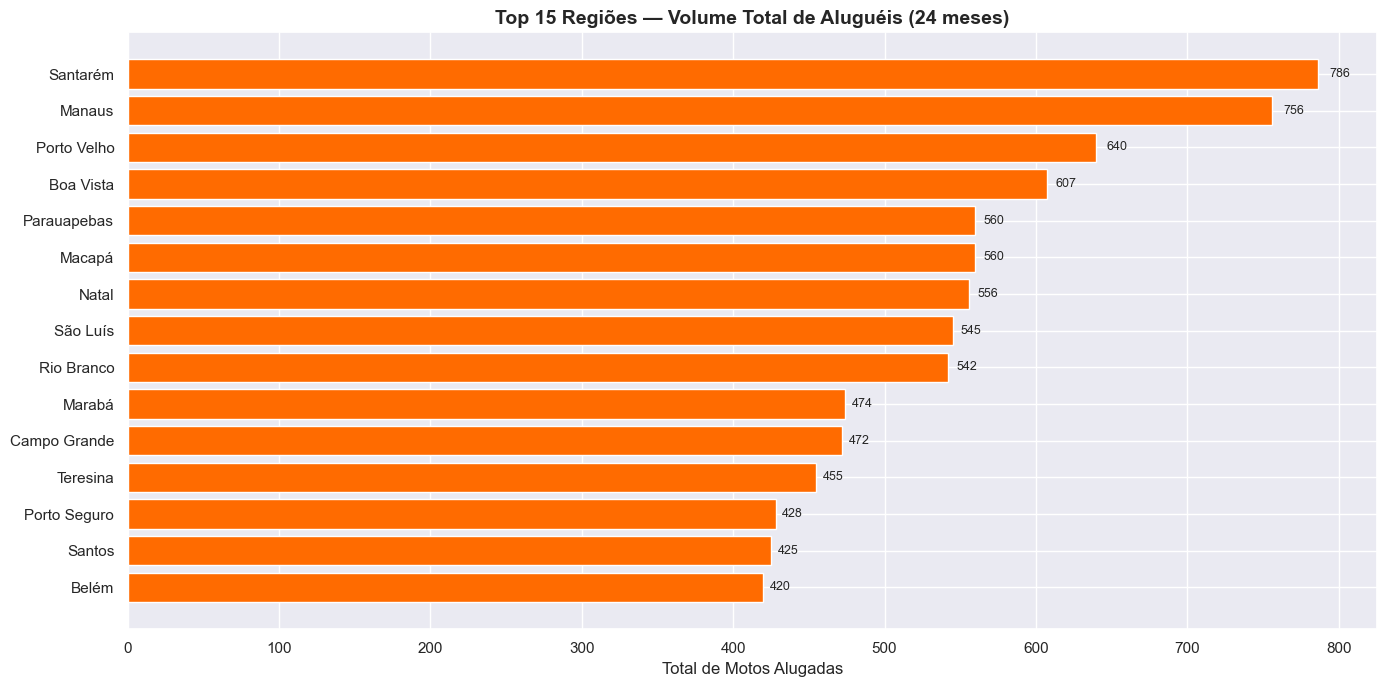

In [24]:
top_regioes = (
    df.groupby('regiao')['media_motos_alugadas_dia']
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_regioes.index, top_regioes.values, color=COR_MOTTU, edgecolor='white')

# Rótulos nas barras
for bar in bars:
    w = bar.get_width()
    ax.text(w + w * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=9)

ax.set_title('Top 15 Regiões — Volume Total de Aluguéis (24 meses)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Motos Alugadas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('data/raw/grafico_top_regioes.png', dpi=150)
plt.show()

---
## 3 — Evolução Mensal — Top 8 Regiões

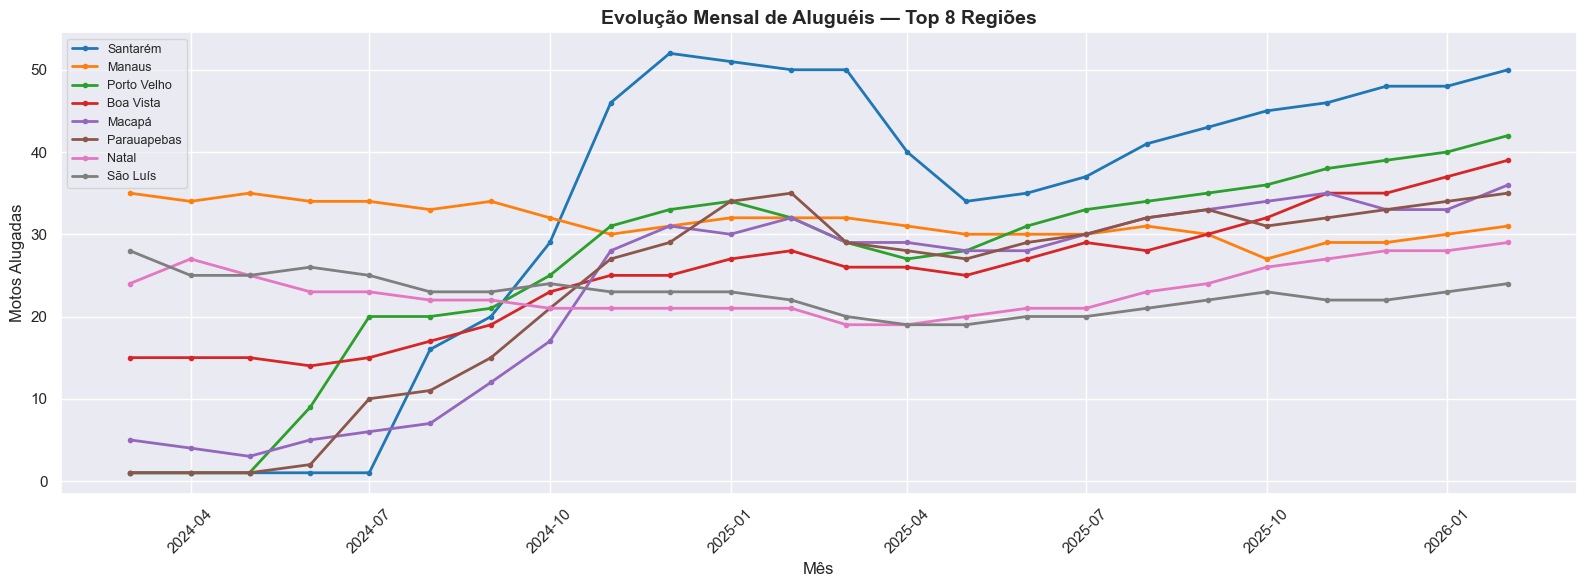

In [25]:
top8 = (
    df.groupby('regiao')['media_motos_alugadas_dia']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

df_top8 = df[df['regiao'].isin(top8)]

fig, ax = plt.subplots(figsize=(16, 6))
palette = sns.color_palette('tab10', n_colors=8)

for i, regiao in enumerate(top8):
    dados = df_top8[df_top8['regiao'] == regiao].sort_values('ano_mes')
    ax.plot(dados['ano_mes'], dados['media_motos_alugadas_dia'],
            label=regiao, linewidth=2, marker='o', markersize=3, color=palette[i])

ax.set_title('Evolução Mensal de Aluguéis — Top 8 Regiões', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Motos Alugadas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/raw/grafico_evolucao_top8.png', dpi=150)
plt.show()

---
## 4 — Heatmap de Sazonalidade (Mês × Região)

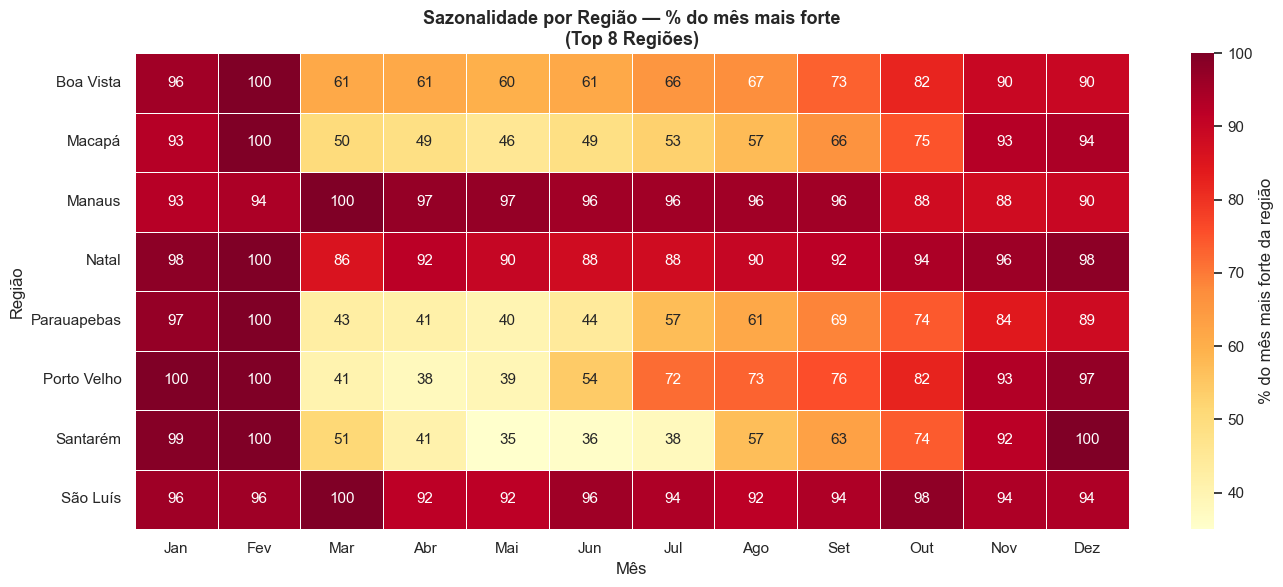

In [26]:
MESES_PT = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

df_heat = df[df['regiao'].isin(top8)].copy()
df_heat['mes_num'] = df_heat['ano_mes'].dt.month
df_heat['mes'] = df_heat['mes_num'].map(MESES_PT)

pivot = (
    df_heat.groupby(['regiao', 'mes_num'])['media_motos_alugadas_dia']
    .mean()
    .unstack()
    .rename(columns=MESES_PT)
)

# Normaliza por linha (cada região em % do seu próprio máximo)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_norm, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% do mês mais forte da região'},
            ax=ax)

ax.set_title('Sazonalidade por Região — % do mês mais forte\n(Top 8 Regiões)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Região')
plt.tight_layout()
plt.savefig('data/raw/grafico_heatmap_sazonalidade.png', dpi=150)
plt.show()

---
## 5 — Crescimento Mês a Mês (MoM%) — Brasil

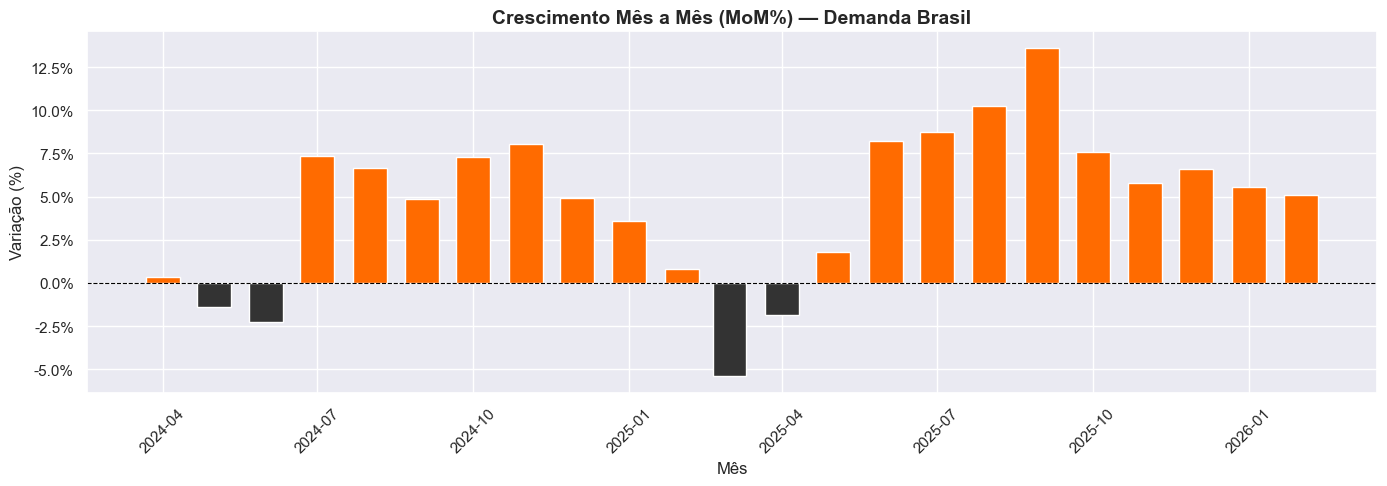

In [27]:
demanda_mensal = demanda_mensal.sort_values('ano_mes')
demanda_mensal['mom_pct'] = demanda_mensal['media_motos_alugadas_dia'].pct_change() * 100

fig, ax = plt.subplots()
cores = [COR_MOTTU if v >= 0 else '#333333' for v in demanda_mensal['mom_pct'].fillna(0)]
ax.bar(demanda_mensal['ano_mes'], demanda_mensal['mom_pct'], color=cores, width=20)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Crescimento Mês a Mês (MoM%) — Demanda Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Variação (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/raw/grafico_mom.png', dpi=150)
plt.show()

---
## 6 — Resumo Estatístico por Região

In [28]:
resumo = (
    df.groupby('regiao')['media_motos_alugadas_dia']
    .agg(
        media='mean',
        mediana='median',
        total='sum',
        minimo='min',
        maximo='max'
    )
    .round(0)
    .sort_values('total', ascending=False)
)

resumo['total'] = resumo['total'].map('{:,.0f}'.format)
resumo['media'] = resumo['media'].map('{:,.0f}'.format)

print('📊 Resumo Estatístico por Região (24 meses):')
resumo

📊 Resumo Estatístico por Região (24 meses):


,media,mediana,total,minimo,maximo
regiao,,,,,
Santarém,33,40.0,786,1.0,52.0
Manaus,32,31.0,756,27.0,35.0
Porto Velho,27,31.0,640,1.0,42.0
Boa Vista,25,26.0,607,14.0,39.0
Macapá,23,29.0,560,3.0,36.0
...,...,...,...,...,...
Passo Fundo,6,4.0,64,1.0,16.0
Lages,3,1.0,61,1.0,13.0
Patos de Minas,2,1.0,42,1.0,5.0
